In [3]:
# Basic imports and setup
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import corner

# Import the new data loader and plotting functions
from analyze_modules import ChelioRun

# get viridis colormap
cmap = plt.get_cmap('viridis')
cmap.set_bad(color='black')
plt.rcParams['figure.dpi'] = 200

In [4]:
def set_white(ax):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.tick_params(axis='x', colors='white', which='both')  # Set color for both major and minor ticks
    ax.tick_params(axis='y', colors='white', which='both')  # Set color for both major and minor ticks

def increase_size(ax, linewidth=3, fontsize=14, legendcols=1, legendloc='best'):
    for l in ax.lines:
        l.set_linewidth(linewidth)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(linewidth)
    ax.set_title(ax.get_title(), fontsize=fontsize)
    ax.xaxis.set_tick_params(width=linewidth)
    ax.yaxis.set_tick_params(width=linewidth)
    ax.xaxis.label.set_size(fontsize)
    ax.yaxis.label.set_size(fontsize)
    ax.xaxis.set_tick_params(labelsize=fontsize)
    ax.yaxis.set_tick_params(labelsize=fontsize)
    if legendloc != 'no':
        ax.legend(fontsize=fontsize, ncols=legendcols, loc=legendloc)

In [5]:
# Define parameters for the matrix
folder = '../output/Atmodeller/'

Tints = np.array([50, 100, 150, 200])
Tmelts = np.array([1000, 2000])
Hoceans = np.array([0.1, 1.0, 10.0])
CtoHs = np.array([0.1, 1.0, 10.0])
NtoCs = np.array([0.01, 0.1, 1.0])
fO2s = np.array([-3, 0, 3])

var_params = [Tmelts, Hoceans, CtoHs, NtoCs, fO2s]
var_param_names = ['Tmelt', 'Hocean', 'CtoH', 'NtoC', 'fO2']
param_log = [False, True, True, True, False]

# Define the parameter grid
param_grid = np.meshgrid(*var_params)
print(param_grid[0].shape)

# Flatten the parameter grid
param_grid = np.array([p.flatten() for p in param_grid])
print(param_grid.shape)

(3, 2, 3, 3, 3)
(5, 162)


In [6]:
Tint = 50
runs = []

for i in range(param_grid.shape[1]):
    ntoc_str = f"{param_grid[3, i]:.1f}" if param_grid[3, i] >= 1.0 else f"{param_grid[3, i]:.1g}"
    run_name = f"Earth_Tint={Tint}_Tmelt={param_grid[0, i]:.0f}_Hocean={param_grid[1, i]:.1f}_CtoH={param_grid[2, i]:.1f}_NtoC={ntoc_str}_fO2={param_grid[4, i]:.0f}"
    print(run_name)
    run = ChelioRun(folder, run_name)#, load_mode='all')
    run.read_data()
    run.convert_to_vmr()
    runs.append(run)

converged_mask = np.array([run.final_convergence_status for run in runs])
converged = converged_mask.sum()
print(f"Number of converged runs: {converged} of {len(runs)}, {converged/len(runs)*100:.2f}%")

Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.01_fO2=-3
No valid data found for run Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.01_fO2=-3
Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.01_fO2=0
No valid data found for run Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.01_fO2=0
Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.01_fO2=3
No valid data found for run Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.01_fO2=3
Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.1_fO2=-3
No valid data found for run Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.1_fO2=-3
Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.1_fO2=0
No valid data found for run Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.1_fO2=0
Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.1_fO2=3
No valid data found for run Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=0.1_fO2=3
Earth_Tint=50_Tmelt=1000_Hocean=0.1_CtoH=0.1_NtoC=1.0_fO2=-3
No valid data found for run Earth_Tint=50

In [7]:
# get outgassed data

vmrs = {}
Psurfs = np.zeros(len(runs))
PTs = []

for i, run in enumerate(runs):
    run_name = run.run_name + '_outgassed'
    p_file = folder + run_name + '/P_BOA.dat'
    vmrs_file = folder + run_name + '/species.dat'
    try:
        with open(p_file, 'r') as f:
            Psurfs[i] = float(f.readline())*1e-6
        with open(vmrs_file, 'r') as f:
            for j, line in enumerate(f):
                if j != 0 and line != '\n':
                    line = line.split()
                    if line[0] == 'CIA_N2N2':
                        mol, vmr = 'N2', float(line[-1].split('&')[0])
                    elif line[0][:3] == 'CIA':
                        continue
                    else:
                        mol, vmr = line[0], float(line[-1])
                    
                    if mol not in vmrs:
                        vmrs[mol] = []
                    vmrs[mol].append(vmr)
        try:
            pt_file = folder + run_name + f'/{run_name}_tp_cut.dat'
            pt = np.loadtxt(pt_file, skiprows=2, usecols=(2,1))
            pt[:,0] *= 1e-6 # dyn/cm^2 to bar
            PTs.append(pt)
        except:
            PTs.append(np.array([[np.nan, np.nan]]))
    except:
        Psurfs[i] = np.nan
        PTs.append(np.array([[np.nan, np.nan]]))

for mol in vmrs.keys():
    vmr = np.array(vmrs[mol])
    vmrs[mol] = np.empty_like(Psurfs)
    vmrs[mol][:] = np.nan
    mask = np.logical_not(np.isnan(Psurfs))
    vmrs[mol][mask] = vmr

converged 15
low P 13
GGchem fails 0
not converged 134


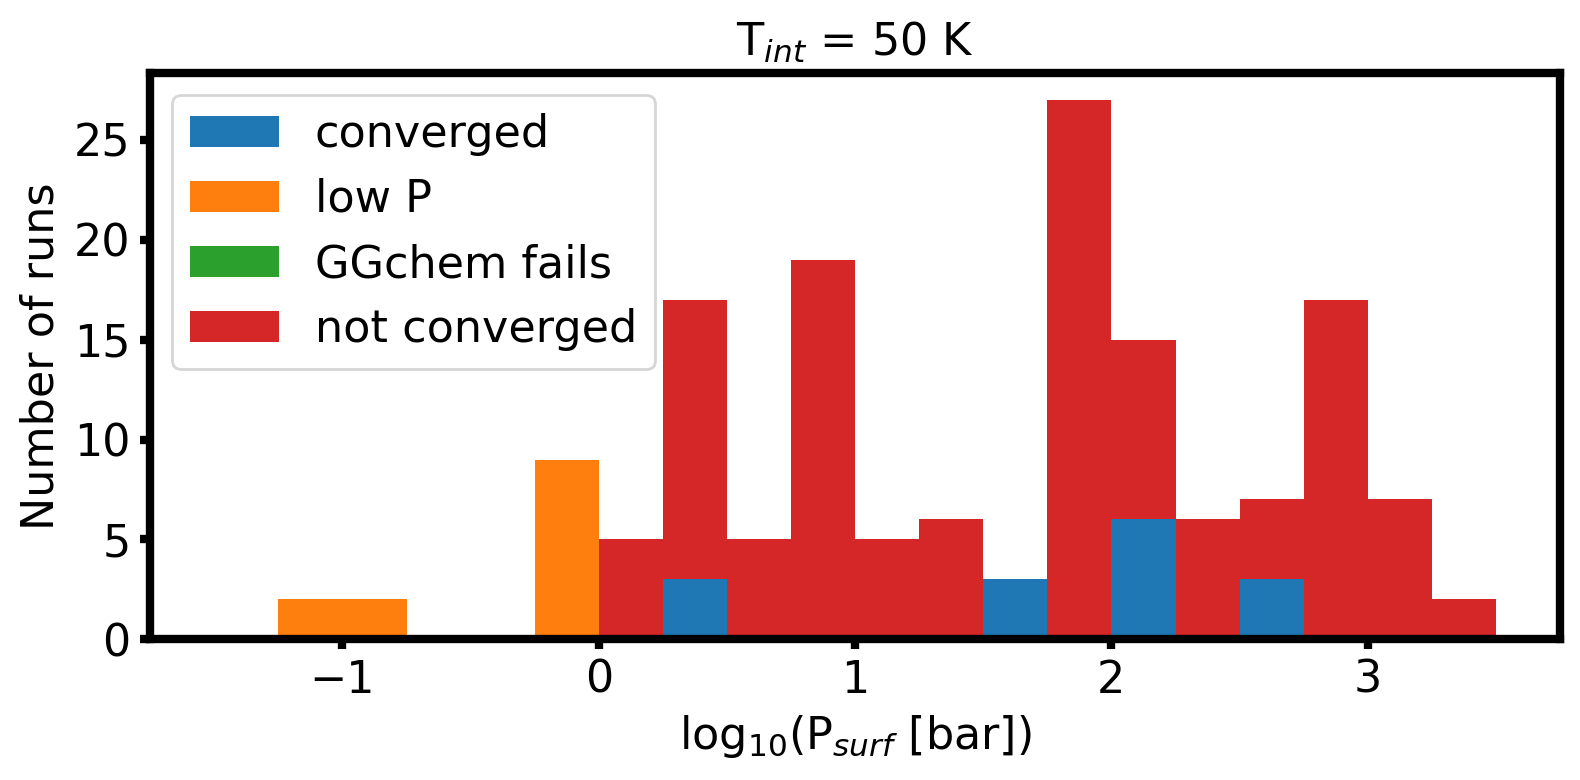

In [8]:
mask_lowP = Psurfs < 1e0
mask_noConv = np.logical_and(np.logical_not(converged_mask), np.logical_not(mask_lowP))
mask_noConv = np.logical_and(mask_noConv, np.logical_not(np.isnan(Psurfs)))
mask_Tconst = np.array([np.all(np.abs(run.temperatures_K[0,:] - 500) < 1e-1) for run in runs])
#mask_GGfail = np.array([run.temperatures_K[0,-1] == 0.0 for run in runs])

if np.sum(mask_noConv) > 0:
    mask_labels = ['converged', 'low P', 'GGchem fails', 'not converged']
    masks = [converged_mask, mask_lowP, mask_Tconst, mask_noConv]
else:
    mask_labels = ['converged', 'low P', 'GGchem fails']
    masks = [converged_mask, mask_lowP, mask_Tconst]

plt.figure(figsize=(8,4))

hist_data = []
for i,mask in enumerate(masks[:]):
    print(mask_labels[i], np.sum(mask))
    hist_data.append(np.log10(Psurfs[mask]))

plt.hist(hist_data, bins=20, range=(-1.5, 3.5), label=mask_labels, stacked=True)

plt.xlabel(r'log$_{10}$(P$_{surf}$ [bar])')
plt.ylabel('Number of runs')
plt.legend()
increase_size(plt.gca(), linewidth=3, fontsize=16, legendloc='best')
plt.title(r'T$_{int}$ = ' + f'{Tint} K', fontsize=16)
plt.tight_layout()

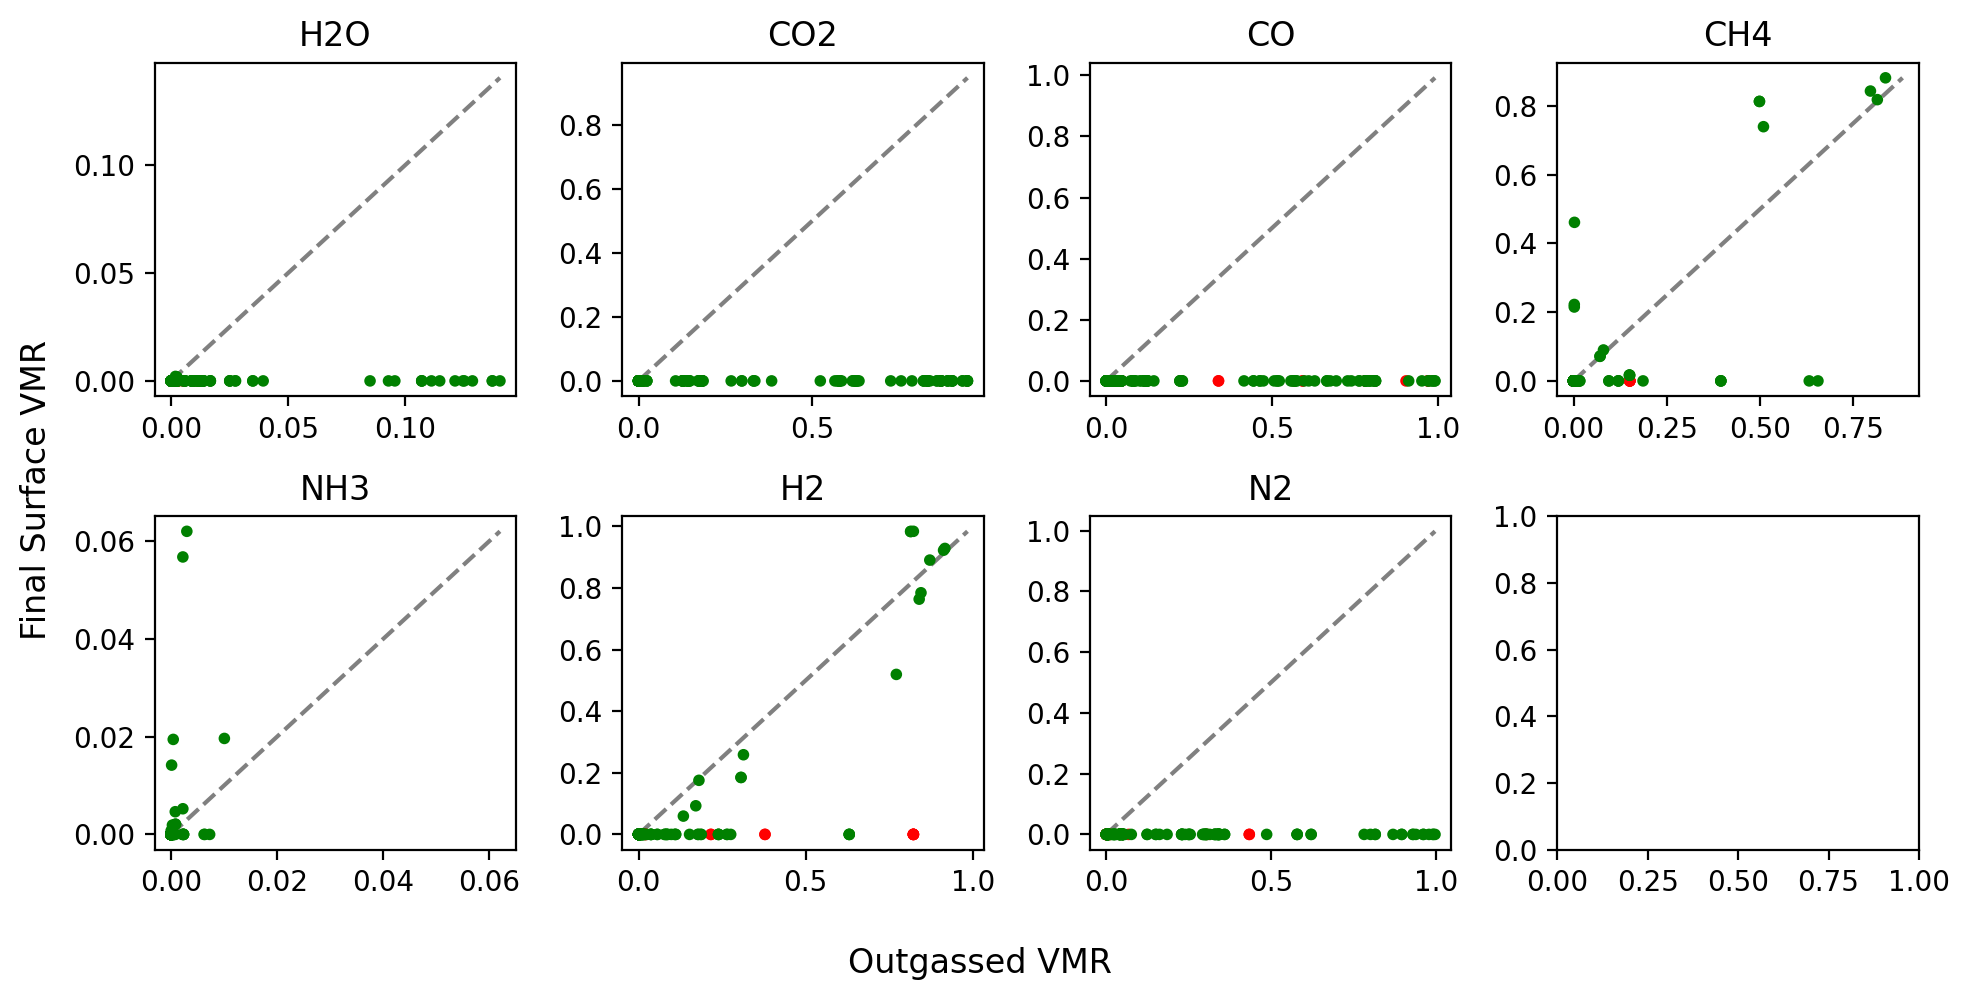

In [9]:
# compare abundances

layer = 0 # (surface layer = 0)
#colors = np.array([run.iterations_read[-1] for run in runs])
#colors = plt.cm.plasma(colors/(np.nanmax(colors)+1))
colors = ['green' if run.iterations_read[-1] > 0 else 'red' for run in runs]

plot_all = True
if plot_all:
    n_mols = len(vmrs.keys())
    n_rows = 2 #np.ceil(np.sqrt(n_mols)).astype('int')
    n_cols = np.ceil(n_mols/n_rows).astype('int')
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(10,5), dpi=200)
    
    for i, mol in enumerate(vmrs.keys()):
        ax = axs[i//n_cols, i%n_cols]
        ggchem_vmr = np.zeros_like(Psurfs)
        for j, run in enumerate(runs):
            if run.final_convergence_status:
                i_mol = run.mol_names.index(mol)
                ggchem_vmr[j] = run.mols_vmr[0, layer, i_mol]

        ax.scatter(vmrs[mol], ggchem_vmr, c=colors, s=10)
        max_vmr = np.max([np.nanmax(vmrs[mol]), np.nanmax(ggchem_vmr)])
        ax.plot(np.linspace(0,max_vmr,100), np.linspace(0,max_vmr,100), "--", color='grey', zorder=-1)
        #ax.plot(np.linspace(0,1,100), np.linspace(0,1,100), "--", color='black')
        #ax.set_xlim(0,1)
        #ax.set_ylim(0,1)
        ax.set_title(mol)

    fig.supxlabel('Outgassed VMR')
    fig.supylabel('Final Surface VMR')

else:
    mol = 'H2'
    fig, ax = plt.subplots(figsize=(5,5), dpi=200)
    for j, run in enumerate(runs):
            if run.final_convergence_status:
                i_mol = run.mol_names.index(mol)
                ggchem_vmr[j] = run.mols_vmr[0, layer, i_mol]

    ax.scatter(vmrs[mol], ggchem_vmr, c=colors, s=100)
    max_vmr = np.max([np.nanmax(vmrs[mol]), np.nanmax(ggchem_vmr)])
    ax.plot(np.linspace(0,max_vmr,100), np.linspace(0,max_vmr,100), "--", color='grey', zorder=-1)
    ax.set_title(f'{mol}, ' + r'T$_{int}$ = ' + f'{Tint} K')
    ax.set_xlabel('Outgassed VMR')
    ax.set_ylabel('Final Surface VMR')
    
    handles = [plt.scatter([], [], c='green', s=100, label='Converged'), plt.scatter([], [], c='red', s=100, label='Not converged')]
    ax.legend(handles=handles, loc='best')

#set_white(ax)
#increase_size(ax, linewidth=3, fontsize=16, legendloc='no')
fig.tight_layout()

#fig.savefig(f'images/Poster_Venice/ggchem_vmr_comparison_{mol}.svg', format='svg', transparent=True)

converged 15
low P 13
GGchem fails 0
not converged 134


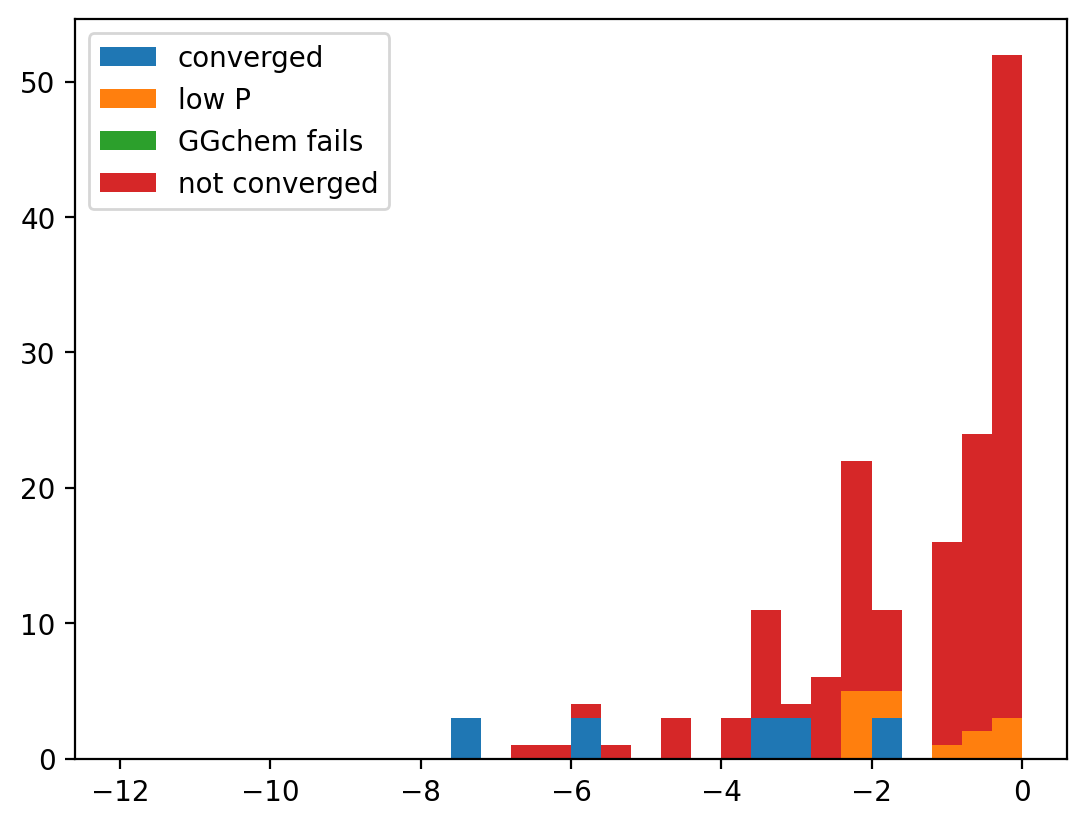

In [10]:
hist_data = []
for i,mask in enumerate(masks):
    print(mask_labels[i], np.sum(mask))
    hist_data.append(np.log10(vmrs['CO2'][mask]))

plt.hist(hist_data, bins=30, range=(-12, 0), label=mask_labels, stacked=True)

plt.legend()

Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=0.1_NtoC=0.01_fO2=-3: 2.3 bar, 82 K 106.08
Min Ts: 45.6567 17.7461
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=0.1_NtoC=0.1_fO2=-3: 2.4 bar, 83 K 106.084
Min Ts: 45.6623 17.9381
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=1.0_NtoC=0.01_fO2=-3: 2.4 bar, 83 K 106.084
Min Ts: 45.6623 17.9381
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.01_fO2=-3: 113.2 bar, 250 K 106.068
Min Ts: 45.6485 17.5433
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.01_fO2=0: 53.9 bar, 202 K 106.075
Min Ts: 45.7025 18.0918
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.1_fO2=-3: 114.6 bar, 251 K 106.07
Min Ts: 45.6489 17.6192
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.1_fO2=0: 55.3 bar, 204 K 106.07
Min Ts: 45.7156 18.2074
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=1.0_fO2=-3: 129.6 bar, 260 K 106.075
Min Ts: 45.7017 17.704
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=1.0_NtoC=0.01_fO2=-3: 409.6 bar, 361 K 106.067
Min Ts: 45.6972 19.7274
Earth_T

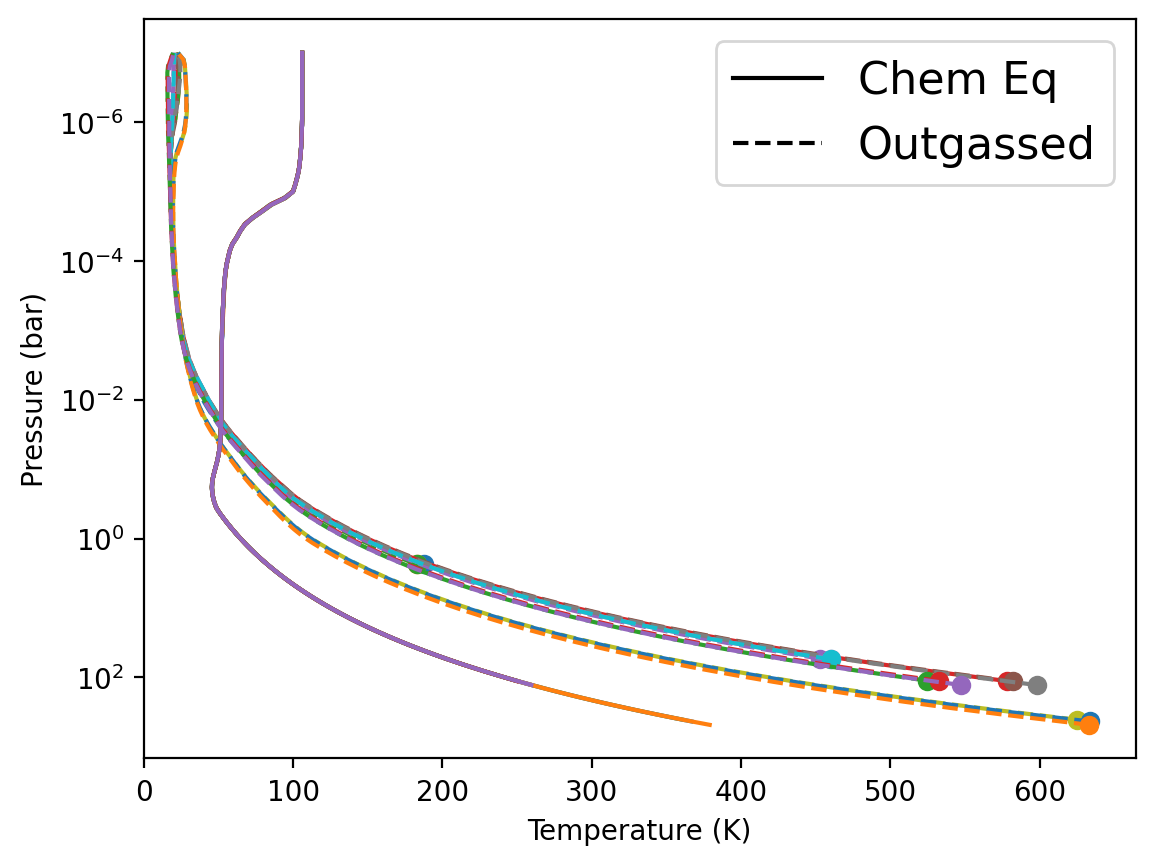

In [11]:
# plot temperature profiles
for i, run in enumerate(runs):
    if run.final_convergence_status:
        if np.all(np.abs(run.temperatures_K[0,:] - 500) > 1e-1):
            print(f'{run.run_name}: {run.pressures_bar[0,0]:.1f} bar, {run.temperatures_K[0,0]:.0f} K', run.temperatures_K[0,-1])
            line = plt.plot(run.temperatures_K[0,:], run.pressures_bar[0,:], label=run.run_name)
            plt.plot(PTs[i][:,1], PTs[i][:,0], color=line[0].get_color(), linestyle='--')
            plt.plot(PTs[i][0,1], PTs[i][0,0], color=line[0].get_color(), marker='o')
            print('Min Ts:', np.min(run.temperatures_K[0,:]), np.min(PTs[i][:,1]))

plt.yscale('log')
plt.gca().invert_yaxis()
plt.xlim(0, None)
#plt.ylim(5e2, 1e0)
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (bar)')
#plt.legend(bbox_to_anchor=(1.1, 0.3))

legend_labels = ['Chem Eq', 'Outgassed']
linestyles = ['-', '--']
handles, labels = [], []
for linestyle, label in zip(linestyles, legend_labels):
    handles.append(plt.Line2D([0], [0], color='black', linestyle=linestyle))
    labels.append(label)
plt.legend(handles=handles, labels=labels, loc='best', fontsize=16)

#increase_size(plt.gca(), linewidth=3, fontsize=16, legendloc='no')

plt.show()

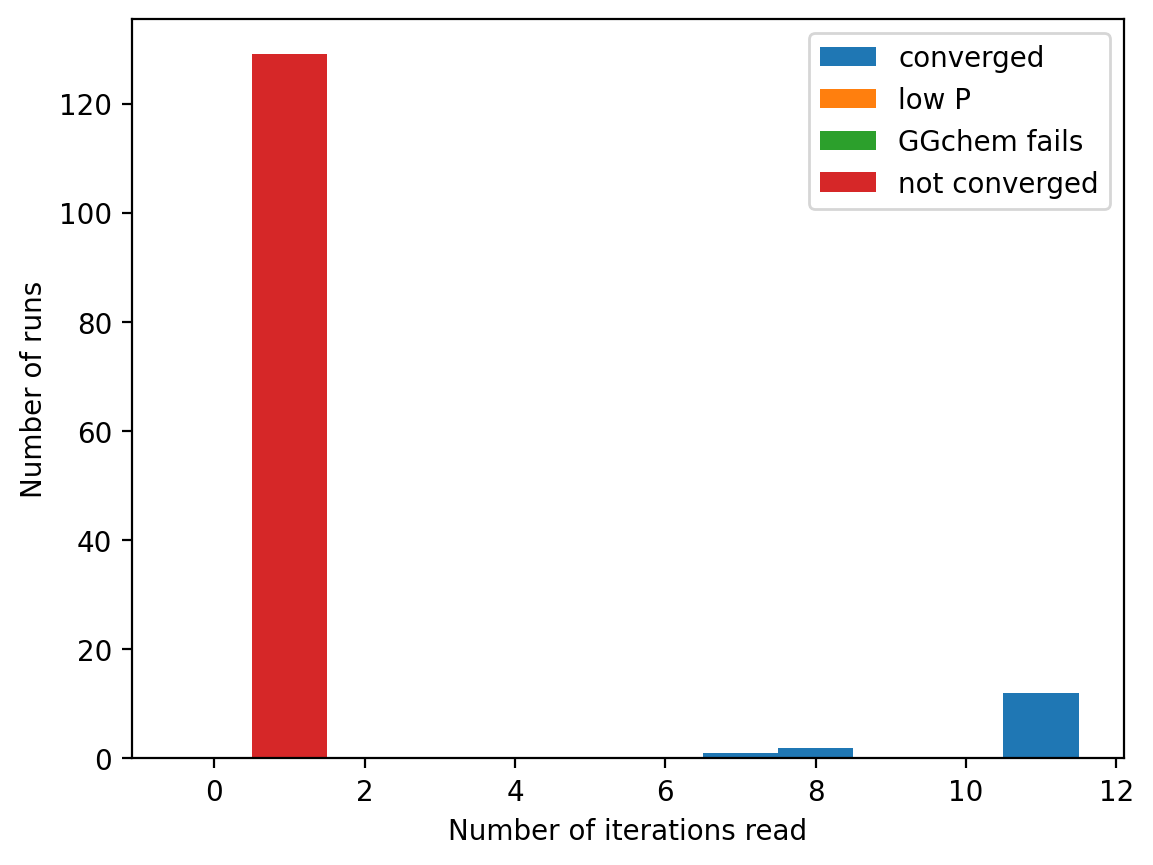

In [12]:
param = 'iterations_read'

param_array = np.array([getattr(run, param) for run in runs])

hist_data = []
for i, mask in enumerate(masks):
    hist_data.append(param_array[mask][:,0])

plt.hist(hist_data, bins=12, range=(-0.5, 11.5), label=mask_labels, stacked=True)
plt.xlabel('Number of iterations read')
plt.ylabel('Number of runs')
plt.legend()
plt.show()

162 162
[nan, nan, nan, nan, nan, nan, nan, 77.2335, 77.3122, nan, 80.6134, 92.7854, nan, 81.7813, 93.1187, 84.6976, 89.052, 95.7592, nan, 81.7813, 117.812, 84.6976, 89.052, 118.212, 118.625, 107.221, 122.535, nan, nan, nan, nan, nan, nan, nan, nan, 77.5349, 87.4141, 92.8811, 92.9608, 87.6127, 93.2444, 93.2899, 92.0178, 96.351, 96.0784, 105.055, 117.454, 118.309, 106.037, 117.848, 118.687, 115.876, 121.656, 122.883, 187.525, 124.078, nan, 182.925, 128.785, 133.195, 202.14, 149.185, 136.778, 182.925, 128.785, 152.96, 202.14, 149.185, 158.239, 268.59, 201.55, 173.185, 202.14, 149.185, 267.452, 268.59, 201.55, 274.432, 383.446, 284.742, 295.954, 137.506, 130.952, 131.625, 142.508, 132.455, 131.886, 159.382, 137.159, nan, 164.058, 144.89, 150.449, 193.939, 150.567, 150.76, 229.363, 176.604, 153.169, 227.398, 232.085, 268.035, 255.299, 242.894, 269.51, 303.234, 271.091, 277.881, 577.84, 452.746, 333.152, 582.409, 460.353, 364.048, 598.26, 483.143, 404.652, 624.871, 460.353, 505.738, 633.423

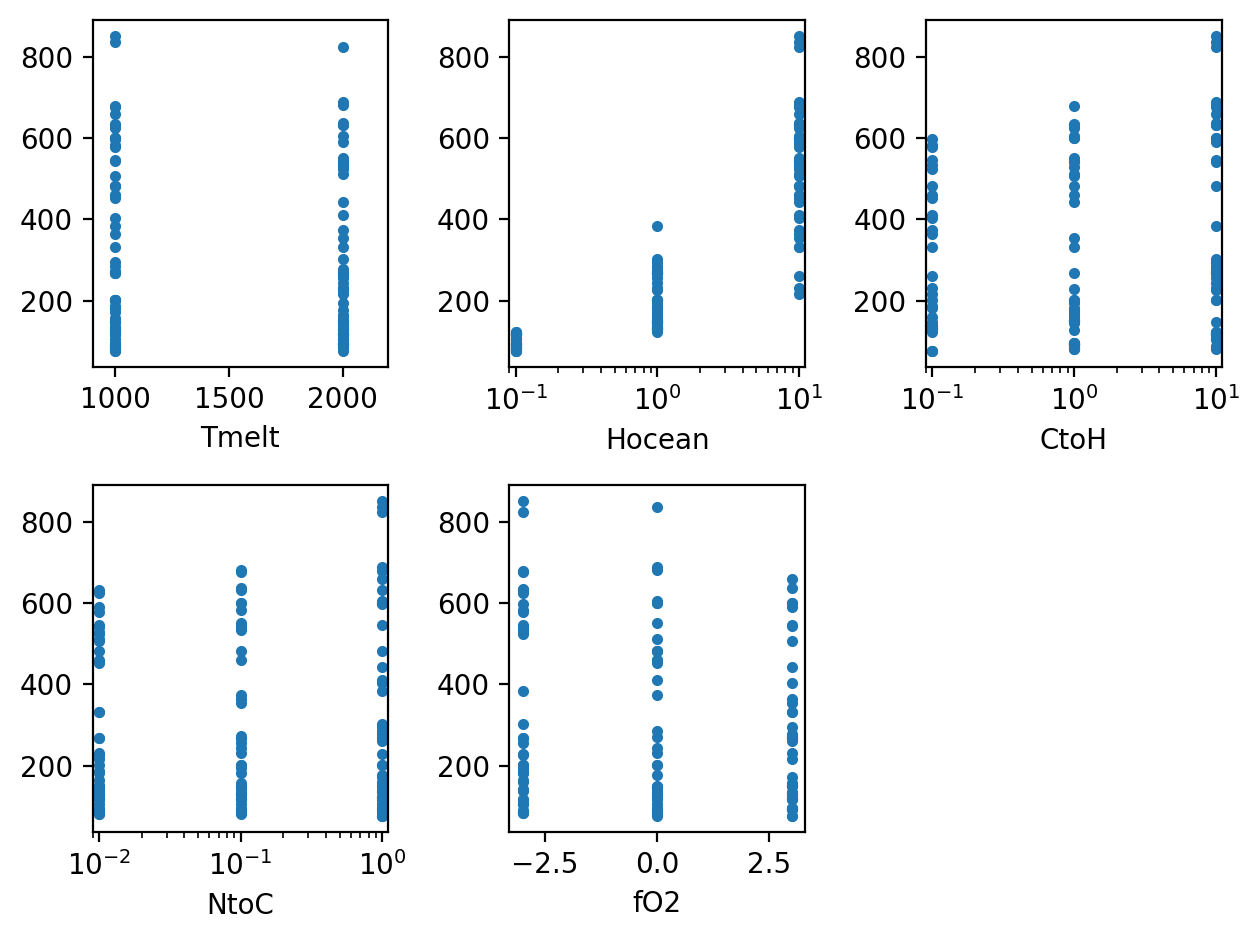

In [13]:
fig, ax = plt.subplots(2,3)
ax = ax.flatten()

print(len(runs), len(PTs))
#y_data = [run.temperatures_K[0,0] if abs(run.temperatures_K[0,0] - 500) > 1e-1 else np.nan for run in runs]
y_data = [PTs[j][0,1] for j in range(len(PTs))]
print(y_data)

for i,p in enumerate(param_grid):
    ax[i].plot(p, y_data, '.')
    if param_log[i]:
        ax[i].set_xscale('log')
    ax[i].set_xlim(p.min()*(1-0.1*np.sign(p.min())), p.max()*(1+0.1*np.sign(p.max())))
    #ax[i].set_yscale('log')
    ax[i].set_xlabel(var_param_names[i])
    #ax[i].set_ylabel('Pressure (bar)')

# delete empty subplots
ax[-1].remove()

fig.tight_layout()

In [14]:
# diagnose failed runs: (P,T)? Composition?

mask_allnan = np.array([np.all(np.isnan(run.temperatures_K[-1,:])) for run in runs])
mask_partial = np.array([np.isnan(run.temperatures_K[-1,-1]) for run in runs])
#mask_partial = np.logical_xor(mask_allnan, mask_noConv)
mask_partial = np.logical_and(~mask_allnan, mask_noConv)

print('All NaN:', np.sum(mask_allnan), np.sum(mask_allnan)/mask_allnan.shape[0]*100)
print('GGchem breaks:', np.sum(mask_partial), np.sum(mask_partial)/mask_allnan.shape[0]*100)
print('Converged:', np.sum(converged_mask), np.sum(converged_mask)/mask_allnan.shape[0]*100)

#print(np.arange(len(runs))[mask_allnan])
#print(np.arange(len(runs))[mask_partial])
#print(np.arange(len(runs))[converged_mask])

All NaN: 89 54.93827160493827
GGchem breaks: 58 35.80246913580247
Converged: 15 9.25925925925926


In [15]:
# get dominant molecular species at surface

# assumes all mol_names are the same!
mol_names = runs[np.arange(len(runs), dtype=int)[converged_mask][0]].mol_names
dom_mol = []

for run in runs:
    if len(run.mols_vmr.shape) == 1:
        dom_mol.append(np.nan)
        continue
    
    surface_vmr = run.mols_vmr[-1, 0, :]
    final_vmr = run.mols_vmr[-1, :, :]
    i_final = np.where(~np.isnan(final_vmr[:,0]))[0][-1]
    final_vmr = final_vmr[i_final, :]

    i_mol = np.argmax(final_vmr)
    dom_mol.append(mol_names[i_mol])

dom_mol = np.array(dom_mol)

In [16]:
names = np.array(['H2', 'He', 'N2', 'CH4', 'CO2', 'H2O', 'NH3', 'CO'])
masses = np.array([2.016, 4.0026, 28.0134, 16.0425, 44.0095, 18.0153, 17.031, 28.010]) # amu
# from https://en.wikipedia.org/wiki/Triple_point
triple_Ts = np.array([13.8033, 2.1768, 63.18, 90.68, 216.55, 273.16, 195.4, 68.1]) # K
triple_Ps = np.array([7.04e3, 5.048e3, 12.6e3, 11.7e3, 517e3, 0.611657e3, 6.06e3, 15.37e3]) # Pa
triple_Ps *= 1e1 # to dyn/cm^2
# from https://en.wikipedia.org/wiki/Critical_point_(thermodynamics)
critical_Ts = np.array([33.20, 5.19, 126.2, 190.8, 304.19, 647.1, 405.5, 133.16]) # K
critical_Ps = np.array([1.300e6, 0.227e6, 3.39e6, 4.64e6, 7.38e6, 22.06e6, 11.28e6, 3.498e6]) # Pa
critical_Ps *= 1e1 # to dyn/cm^2

mols = {name: {'mass': mass, 'triple': [Tt, Pt], 'critical': [Tc, Pc]} for name, mass, Tt, Pt, Tc, Pc in zip(names, masses, triple_Ts, triple_Ps, critical_Ts, critical_Ps)}

# psat from GGchem
mmHg = 1.3328e+03 # dyn/cm^2
bar = 1.0e+06 # dyn/cm^2

def p_sat(T, species, mask=True):
    
    if species == 'H2':
        # NIST (21-32K)
        psat = 10.0**(3.54314 - 99.395/(T + 7.726))*bar
        if mask:
            mask = (T < 21.0) | (T > 32.0)
            psat[mask] = np.nan
        return psat

    elif species == 'He':
        psat = np.empty_like(T)
        psat.fill(np.nan)  # He does not have a saturation pressure in the range
        return psat
         
    elif species == 'N2':
        # NIST (63-126K)
        psat = 10.0**(3.7362 - 264.651/(T - 6.788))*bar
        if mask:
            mask = (T < 63.0) | (T > 126.0)
            psat[mask] = np.nan
        return psat

    elif species == 'CH4':
        # only solid
        # NIST (90-190K) and GGchem
        # Prydz, R.; Goodwin, R.D., J. Chem. Thermodyn., 1972, 4,1 
        psat = 10.0**(3.9895 - 443.028/(T-0.49))*bar
        if mask:
            mask = (T < 90.0) | (T > 190.0)
            psat[mask] = np.nan
        return psat
    
    elif species == 'CO2':
        # Yaws' Chemical Properties Handbook (McGraw-Hill 1999) (216-305K), GGchem
        C = np.array([35.0187E+00, -1.5119E+03, -1.1335E+01, 9.3383E-03, 7.7626E-10])
        psat = C[0] + C[1] / T + C[2] * np.log10(T) + C[3] * T + C[4] * T**2
        psat = 10**psat * mmHg
        if mask:
            mask = (T < 216.0) | (T > 305.0)
            psat[mask] = np.nan
        return psat

    elif species == 'H2O':
        
            # Ackerman & Marley 2001 (liquid!), GGchem
            # TC = T - 273.15
            # psat_l = 6112.1*np.exp((18.729*TC - TC**2/227.3)/(TC + 257.87))
            # Yaws' Chemical Properties Handbook (McGraw-Hill 1999) (273-647K)
            C = np.array([29.8605e+00, -3.1522e+03, -7.3037e+00, 2.4247e-09, 1.8090e-06])
            psat = C[0] + C[1] / T + C[2] * np.log10(T) + C[3] * T + C[4] * T**2
            psat = 10**psat * mmHg
            psat_final = psat.copy()
    
            # Ackerman & Marley 2001 (solid), GGchem
            TC   = np.minimum(2000.0,T)-273.15 # T[degree Celsius]
            psat = 6111.5*np.exp((23.036*TC - TC**2/333.7)/(TC + 279.82))
            psat_final[T<273.16] = psat[T<273.16]

            # Haldemann+ 2020
            #psat = 0.05 + 2.95 * (T/1000 - 1)/39 # GPa
            #psat = psat * 1e+10 # dyn/cm^2
            #psat_final[T>647.0] = psat[T>647.0]

            if mask:
                mask = T > 647.0
                psat_final[mask] = np.nan

            return psat_final
    
    elif species == 'NH3':
        # CRC Handbook of Chemistry and Physics (Weast 1971), GGchem
        psat = np.exp(10.53 - 2161.0/T - 86596.0/T**2)*bar
        if mask:
            mask = T > mols['NH3']['critical'][0]  # 405.5 K
            psat[mask] = np.nan

        # NIST (164-371.5K)
        # psat = 10.0**(3.18757 - 506.713/(T - 80.78))*bar
        # psat[T>239.6] = 10**(4.86886 - 1113.928/(T[T>239.6] - 10.409))*bar
        # if mask:
        #     mask = (T < 164.0) | (T > 371.5)
        #     psat[mask] = np.nan
        
        return psat
    
    elif species == 'CO':
        # Yaws' Chemical Properties Handbook (McGraw-Hill 1999) (68-132K), GGchem
        C = np.array([51.8145E+00, -7.8824E+02, -2.2734E+01, 5.1225E-02, 4.6603E-11])
        psat = C[0] + C[1] / T + C[2] * np.log10(T) + C[3] * T + C[4] * T**2
        psat = 10**psat * mmHg
        if mask:
            mask = (T < 68.0) | (T > 132.0)
            psat[mask] = np.nan
        return psat

7 7
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=1.0_NtoC=1.0_fO2=-3 32.7219 -1.9807216585960175 1.3812468839805487 N2
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=0.01_fO2=3 258.765 2.8366278889636485 2.8843784223613205 N2
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=0.1_fO2=-3 32.7219 -1.9807216585960175 1.3812468839805487 N2
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=0.1_fO2=3 258.017 2.8578955077876613 2.9052895378277173 N2
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=1.0_fO2=-3 31.7673 -1.544546031221372 2.4274065785346064 N2
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=1.0_fO2=0 259.479 2.31465708627085 2.457227692693115 N2
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=1.0_fO2=3 270.166 3.010355088181973 3.0580234321862996 N2
Earth_Tint=50_Tmelt=2000_Hocean=1.0_CtoH=1.0_NtoC=0.1_fO2=-3 289.437 1.79694117788163 1.844750465380336 CO2
Earth_Tint=50_Tmelt=2000_Hocean=1.0_CtoH=1.0_NtoC=1.0_fO2=-3 260.173 1.915127986285682 1.9625487943434832 N2
Earth_Ti

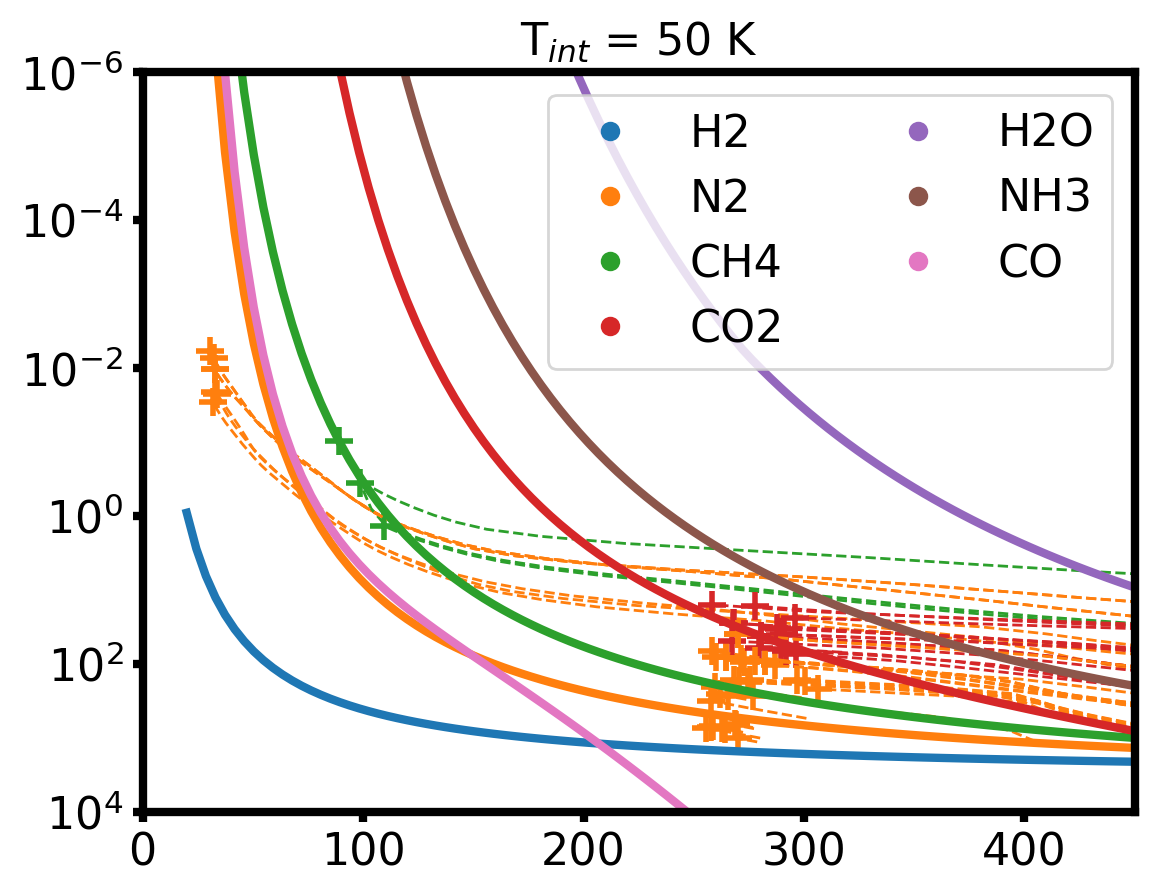

In [17]:
# plot runs, where GGchem breaks "midway" (mask_partial)
# plot (T,P) of breaking point, with color indicating dominant species (at surface)

# ALSO INDICATE DOMINANT SPECIES AT BREAK POINT!!!

unique_mols = names[names != 'He']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']
print(len(colors), len(unique_mols))

def get_last_nonnan(array):
    last_nonnan = array[~np.isnan(array)]
    return last_nonnan[-1]

optional_lines = []
for i, run in enumerate(runs):
    if not mask_partial[i]:
        continue
    T_break = get_last_nonnan(run.temperatures_K)
    P_break = get_last_nonnan(run.pressures_bar)
    print(run.run_name, T_break, np.log10(P_break), np.log10(run.pressures_bar[0,0]), dom_mol[i])

    color = colors[np.where(unique_mols == dom_mol[i])[0][0]]

    line = plt.plot(run.temperatures_K[0,:], run.pressures_bar[0,:], color=color, linestyle='--', linewidth=2)
    optional_lines.append(line)
    plt.plot(T_break, P_break, '+', mew=2, ms=10, color=color) # mew=marker edge width, ms=marker size

vapor_T = np.linspace(20, 450, 100)
for i, mol in enumerate(unique_mols):
    vapor_P = p_sat(vapor_T, mol, mask=False)
    plt.plot(vapor_T, vapor_P*1e-6, color=colors[i])

plt.yscale('log')
#plt.gca().invert_yaxis()
plt.xlim(0, 450)
plt.ylim(1e4, 1e-6)

legend_handles = [plt.plot([], [], 'o', color=colors[i], label=unique_mols[i])[0] for i in np.arange(len(unique_mols))] # -1 ro avoid NaN!
legend_labels = unique_mols
plt.gca().legend(legend_handles, legend_labels)

plt.title(r'T$_{int}$ = ' + f'{Tint} K')
increase_size(plt.gca(), linewidth=3, fontsize=16, legendloc='upper right', legendcols=2)
for line in optional_lines:
    # set width of line to 2
    line[0].set_linewidth(1)

Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=1.0_NtoC=1.0_fO2=-3 32.7219 1.8564000000000007
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=0.01_fO2=3 258.765 8.043000000000006
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=0.1_fO2=-3 32.7219 1.8564000000000007
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=0.1_fO2=3 258.017 8.170999999999992
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=1.0_fO2=-3 31.7673 1.7685999999999993
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=1.0_fO2=0 259.479 26.25200000000001
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=10.0_NtoC=1.0_fO2=3 270.166 8.607000000000028
Earth_Tint=50_Tmelt=2000_Hocean=1.0_CtoH=1.0_NtoC=0.1_fO2=-3 289.437 27.873999999999967
Earth_Tint=50_Tmelt=2000_Hocean=1.0_CtoH=1.0_NtoC=1.0_fO2=-3 260.173 7.951000000000022
Earth_Tint=50_Tmelt=2000_Hocean=1.0_CtoH=10.0_NtoC=0.01_fO2=-3 261.955 8.020000000000039
Earth_Tint=50_Tmelt=2000_Hocean=1.0_CtoH=10.0_NtoC=0.01_fO2=0 268.633 8.241000000000042
Earth_Tint=50_Tmelt=2000_Hocean=1

(1000.0, 1e-06)

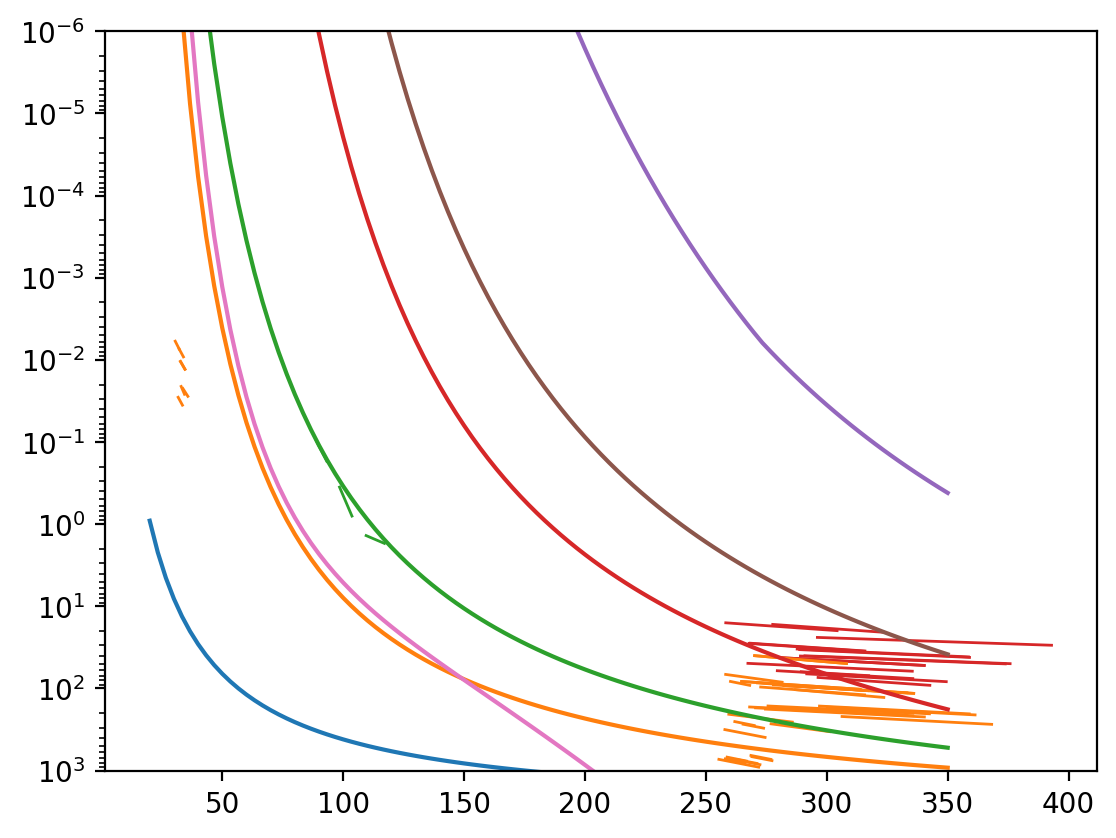

In [18]:
optional_lines = []
for i, run in enumerate(runs):
    if not mask_partial[i]:
        continue
    P_break = get_last_nonnan(run.pressures_bar)
    i_break = np.where(run.pressures_bar[0,:] == P_break)[0][0]
    
    T_break = run.temperatures_K[0,i_break]
    T_step = run.temperatures_K[0,i_break-1] - T_break

    print(run.run_name, T_break, T_step)

    color = colors[np.where(unique_mols == dom_mol[i])[0][0]]

    #plt.plot((T_break), T_step, '+', mew=2, ms=10, color=color) # mew=marker edge width, ms=marker size
    plt.plot(run.temperatures_K[0,i_break-1:], run.pressures_bar[0,i_break-1:], '-', color=color, linewidth=1)

vapor_T = np.linspace(20, 350, 100)
for i, mol in enumerate(unique_mols):
    vapor_P = p_sat(vapor_T, mol, mask=False)
    plt.plot(vapor_T, vapor_P*1e-6, color=colors[i])


#plt.ylim(0, None)

plt.yscale('log')
plt.ylim(1e3, 1e-6)
#plt.xlim(220, 340)


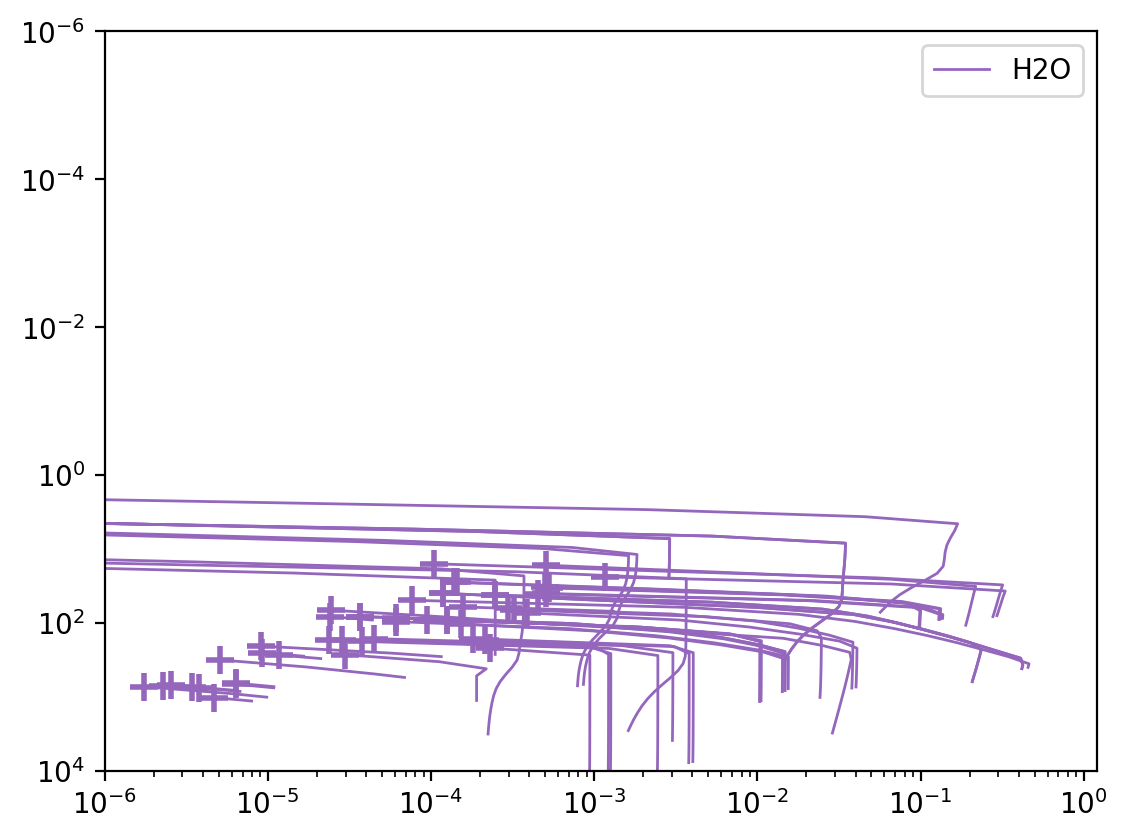

In [19]:
for i, run in enumerate(runs):
    if not mask_partial[i]:
        continue
    mol_to_plot = 'H2O'
    to_plot = run.mols_vmr
    i_mol = run.mol_names.index(mol_to_plot)
    to_plot = to_plot[0,:,i_mol]

    break_point = [get_last_nonnan(to_plot), get_last_nonnan(run.pressures_bar)]

    color = colors[np.where(unique_mols == mol_to_plot)[0][0]]

    plt.plot(to_plot, run.pressures_bar[0,:], color=color, linestyle='-', linewidth=1, label=mol_to_plot)
    plt.plot(break_point[0], break_point[1], '+', mew=2, ms=10, color=color, zorder=1000) # mew=marker edge width, ms=marker size

plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-6, 1.2e0)
plt.ylim(1e4, 1e-6)

# make legend labels unique
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='best')


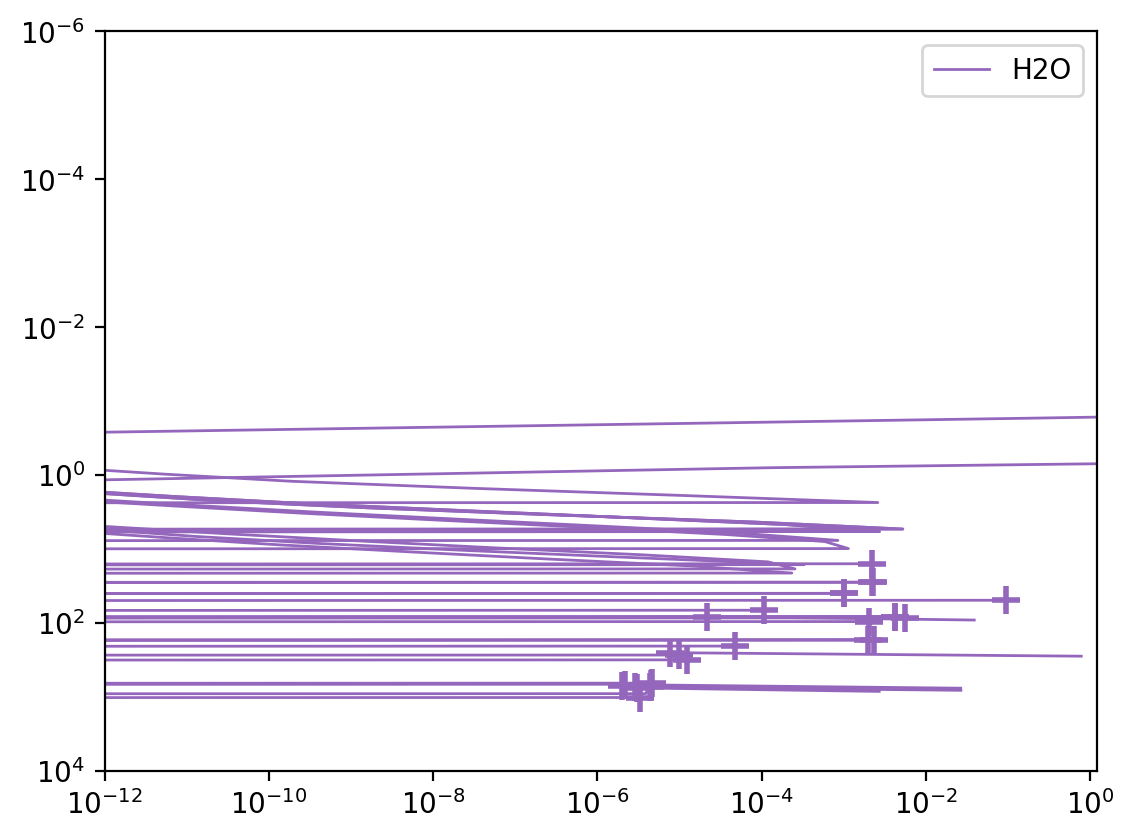

In [20]:
for i, run in enumerate(runs):
    if not mask_partial[i]:
        continue
    mol_to_plot = 'H2O'
    to_plot = run.dusts_vmr
    i_mol = run.dust_names.index(mol_to_plot)
    to_plot = to_plot[0,:,i_mol]

    break_point = [get_last_nonnan(to_plot), get_last_nonnan(run.pressures_bar)]

    color = colors[np.where(unique_mols == mol_to_plot)[0][0]]

    plt.plot(to_plot, run.pressures_bar[0,:], color=color, linestyle='-', linewidth=1, label=mol_to_plot)
    plt.plot(break_point[0], break_point[1], '+', mew=2, ms=10, color=color, zorder=1000) # mew=marker edge width, ms=marker size

plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-12, 1.2e0)
plt.ylim(1e4, 1e-6)

# make legend labels unique
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='best')

(10000.0, 1e-06)

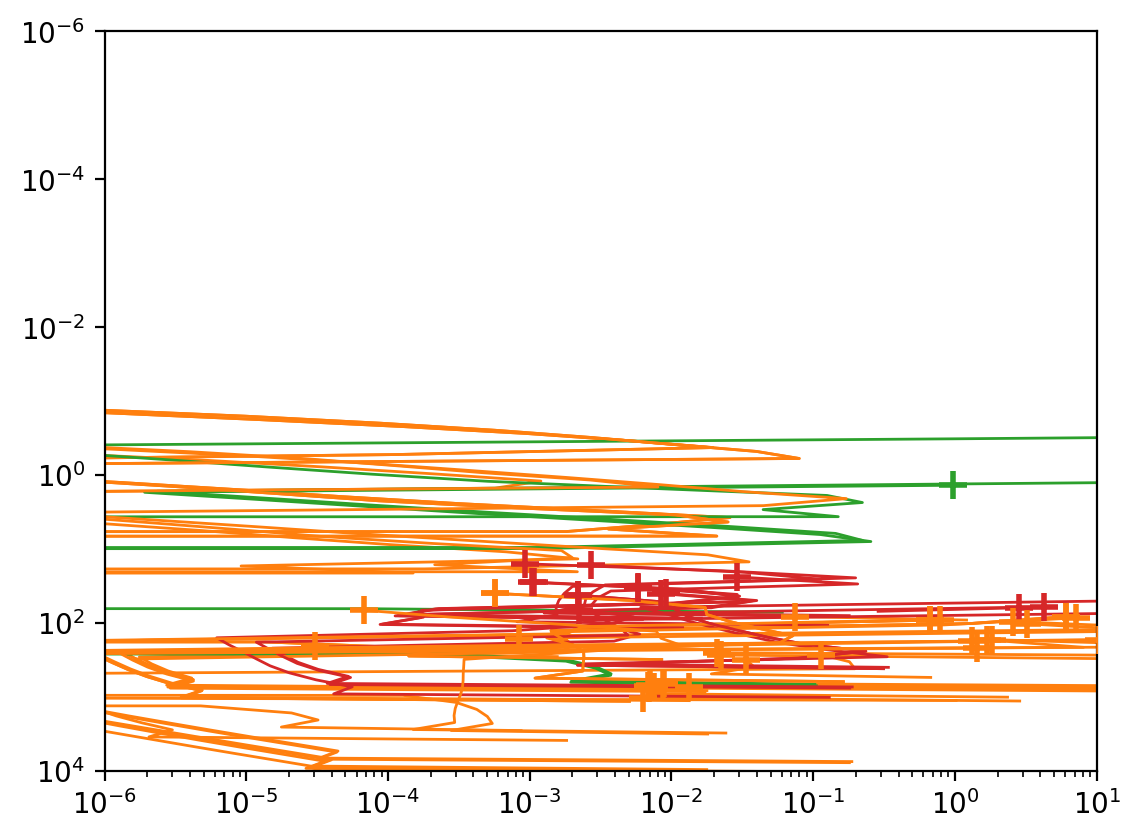

In [21]:
for i, run in enumerate(runs):
    if not mask_partial[i]:
        continue
    to_plot = run.dust_to_gas_mr[0,:]
    break_point = [get_last_nonnan(to_plot), get_last_nonnan(run.pressures_bar)]

    color = colors[np.where(unique_mols == dom_mol[i])[0][0]]

    plt.plot(to_plot, run.pressures_bar[0,:], color=color, linestyle='-', linewidth=1)
    plt.plot(break_point[0], break_point[1], '+', mew=2, ms=10, color=color, zorder=1000) # mew=marker edge width, ms=marker size

plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-6, 1e1)
plt.ylim(1e4, 1e-6)

In [22]:
test_abunds = np.array([8.46, 7.83, 8.69])
test_abunds = 10**(test_abunds-12)
print(test_abunds)

test_abunds = np.array([8.47, 7.87, 8.73])
test_abunds = 10**(test_abunds-12)
print(test_abunds)

[2.88403150e-04 6.76082975e-05 4.89778819e-04]
[2.95120923e-04 7.41310241e-05 5.37031796e-04]


1 1
2 32
3 243
4 1024
5 3125


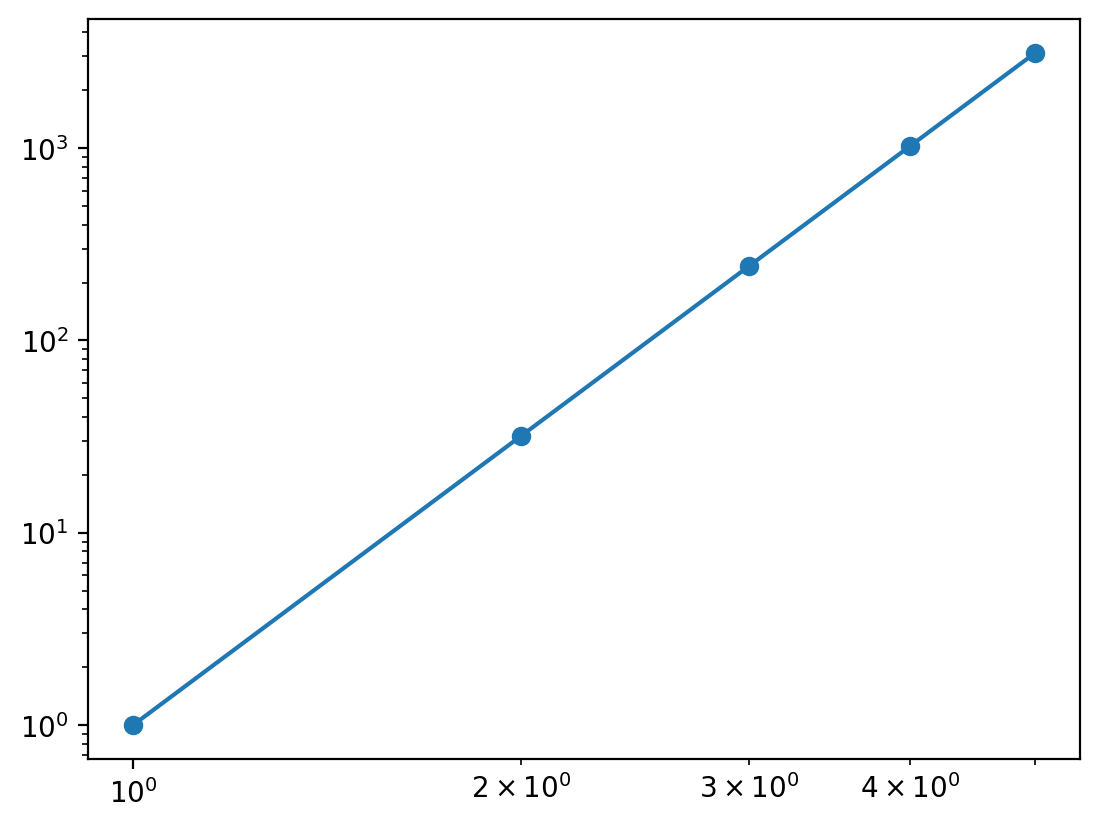

In [34]:
test_x = np.arange(5)+1
test_y = test_x ** 5
for i in range(len(test_x)):
    print(test_x[i], test_y[i])

plt.plot(test_x, test_y, 'o-')
plt.xscale('log')
plt.yscale('log')